In [13]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np
import os

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import compare, make_overview, smoothen
from myio import read_in_weather_data

In [6]:
%matplotlib inline

In [7]:

fdir = '../../Data/Calibration Data/Sinarmas/Clean data'

fpath = os.path.join(fdir,'Yield/Knde-1993.csv')

dfo = pd.read_csv(fpath)
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
dfo = dfo.dropna(how='all')

fpath = os.path.join(fdir, 'Weather/KNDE.csv')

dfw = read_in_weather_data(fpath)

In [8]:
list(dfw)

['Solar', 'T-max', 'T-min', 'RelHum', 'Precip', 'wind']

In [11]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField
from palmsim import Indeterminate
from palmsim import Fronds

# 1. Initialize the model
dt = 10

# different variety!
Indeterminate.parameters['potential_mass_a']['value'] = 19 # 23 -> 19 kg_DM as asymptotic value
Fronds.parameters['initiation_rate_a']['value'] = 22 # 25 -> 22 fronds/year as asymptotic value

p = PalmField(year_of_planting=1992, dt=dt)

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 30

duration = nyears*365

df = p.run(duration=duration)

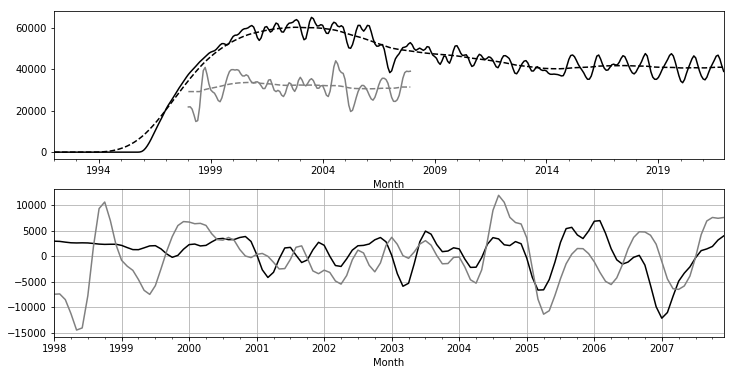

In [39]:
sm = df['generative_bunch_count (1/ha/mo)']
so = dfo['BC (1/ha/mo)'] 

sm = df['generative_bunch_weight (kg)']
so = dfo['ABW (kg)'] 

sm = df['generative_FFB_production (t/ha/yr)']
so = 12*1000*dfo['Y (t/ha/mo)']

s1 = smoothen(sm, window=6, min_periods = 3, fillna = True)
s2 = smoothen(so, window=6, min_periods = 3, fillna = True)

ix0 = s1.index.get_loc(s2.index[0])
ix1 = s1.index.get_loc(s2.index[-1])

ix2s = s2.index

nx = 1

ix0e = ix0 - nx
ix1e = ix1 + nx

s1mm = smoothen(sm,window=60, min_periods=36)
s2mm = smoothen(so,window=60, min_periods=36)

t0 = s1.index[0]

s1a = s1 - s1mm
s2a = s2 - s2mm

s1a = s1a.loc[ix2s]
s2a = s2a.loc[ix2s]

fig, axes = plt.subplots(2,1,figsize=(12,6))

ax = axes[0]

s1mm.plot(c='black',ls='dashed',ax=ax)
s2mm.plot(c='grey',ls='dashed',ax=ax)
s1.plot(c='black',ax=ax)
s2.plot(c='grey',ax=ax)

ax = axes[1]

s1a.plot(c='black',ax=ax)
s2a.plot(c='grey',ax=ax)

ds = (s1a-s2a).resample('D').interpolate()

ds.hist(bins=100)

Saving at: plots\KNDE.png


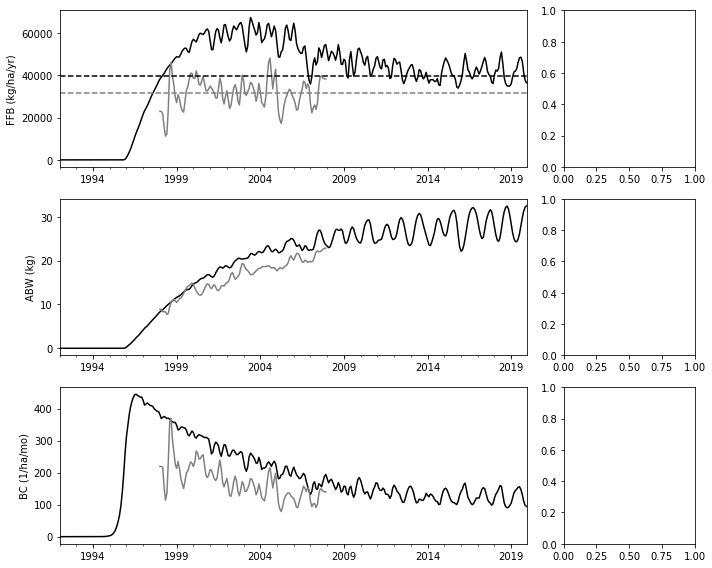

In [40]:
sname = 'KNDE'

make_overview(df, dfo, sname, window=3)

Saving at: plots\KNDE.png


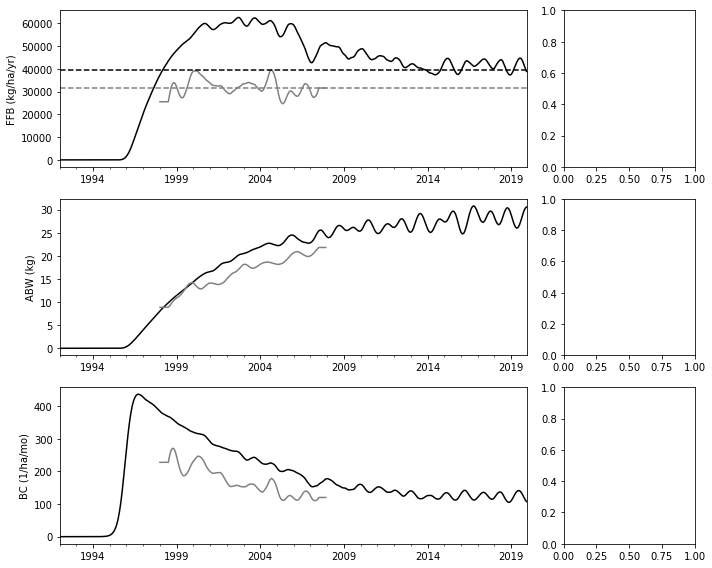

In [41]:
make_overview(df, dfo, sname, window=12)